In [15]:
import geopandas as gpd
from shapely.geometry import LineString
from argopy import ArgoIndex
import matplotlib.pyplot as plt
import contextily as cx
import argopy
import gsw

import os
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import numpy as np

Obtención de la boyas argo con los datos de hace siete días hasta hoy

In [16]:
# ------------------------------------------------------------------
# Caja espacio-temporal: [lon_min, lon_max, lat_min, lat_max,
#                          pres_min, pres_max, fecha_min, fecha_max]
# ------------------------------------------------------------------

# BOX = [-14.0, -4.5, 38.0, 46.0, 0, 4000, "2026-06-15", "2026-07-01"]

# fetcher = argopy.DataFetcher()  # por defecto: src='erddap', mode='standard', ds='phy'
# fetcher = fetcher.region(BOX)



# Fechas para atras desde hoy
fecha_hoy = datetime.now().strftime("%Y-%m-%d")
fecha_hace_una_semana = (datetime.now() - timedelta(days=7)).strftime("%Y-%m-%d")

BOX = [-14.0, -4.5, 38.0, 46.0, 0, 4000, fecha_hace_una_semana, fecha_hoy]

fetcher = argopy.DataFetcher()
fetcher = fetcher.region(BOX)



ds = fetcher.to_xarray()
df = ds.to_dataframe().reset_index()

# Columnas relevantes (hay más: QC, _ADJUSTED, etc. en modo 'standard')
cols = ["PLATFORM_NUMBER", "CYCLE_NUMBER", "TIME", "LATITUDE", "LONGITUDE",
        "PRES", "TEMP", "PSAL"]
df = df[cols].sort_values(["PLATFORM_NUMBER", "TIME", "PRES"])

print(f"Filas (boya-ciclo-profundidad): {len(df)}")
print(f"Boyas distintas: {df.PLATFORM_NUMBER.nunique()}")

display(df[['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'TIME', 'LATITUDE', 'LONGITUDE']].drop_duplicates())

df['SA'] = gsw.SA_from_SP(df['PSAL'], df['PRES'], df['LONGITUDE'], df['LATITUDE'])  # Salinidad Absoluta
df['CT'] = gsw.CT_from_t(df['SA'], df['TEMP'], df['PRES'])                                # Temperatura Conservativa
df['rho'] = gsw.rho(df['SA'], df['CT'], df['PRES'])                                              # Densidad (kg/m³)
sigma0 = gsw.sigma0(df['SA'], df['CT'])                                                    # Densidad potencial referida a 0 dbar
N2, p_mid = gsw.Nsquared(df['SA'], df['CT'], df['PRES'])                                  # Frecuencia de Brunt-Väisälä

df_surf = df.sort_values("PRES").groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"]).first().reset_index()

gdf = gpd.GeoDataFrame(
    df_surf,
    geometry=gpd.points_from_xy(df_surf.LONGITUDE, df_surf.LATITUDE),
    crs="EPSG:4326",
).to_crs(epsg=3857)

df = df.sort_values(["PLATFORM_NUMBER", "CYCLE_NUMBER", "PRES"])

df["rho_columna_superior"] = (
    df.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"])["rho"]
    .transform(lambda x: x.expanding().mean().shift(1)).fillna(df['rho'])
)

df['z_metros'] = 10000*df['PRES']/(df['rho_columna_superior'] * 9.81)

df.drop(['SA', 'CT'], inplace = True, axis = 1)
df

Filas (boya-ciclo-profundidad): 3845
Boyas distintas: 8


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE
2739,1902726,60,2026-07-02 14:06:58,44.130230,-9.939110
2449,2903801,27,2026-07-02 05:37:20,44.095072,-9.794478
485,4903683,36,2026-06-30 22:41:20,44.643828,-11.412585
2547,5906997,27,2026-07-02 05:48:00,38.519265,-10.689143
1482,6902887,78,2026-07-01 08:39:00,39.632453,-13.125322
3748,6990667,71,2026-07-04 20:36:00,39.506483,-12.832905
0,7900526,258,2026-06-30 21:02:20,44.752370,-5.599510
2644,7901143,92,2026-07-02 11:40:20,41.956445,-10.590150


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,PRES,TEMP,PSAL,rho,rho_columna_superior,z_metros
2739,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,0.960000,19.198000,35.601002,1025.437585,1025.437585,0.954318
2740,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,2.080000,19.202999,35.598999,1025.439669,1025.437585,2.067688
2741,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,3.080000,19.205000,35.601002,1025.445060,1025.438627,3.061766
2742,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,4.000000,19.202999,35.599998,1025.448838,1025.440771,3.976312
2743,1902726,60,2026-07-02 14:06:58,44.130230,-9.93911,5.080000,19.202999,35.599998,1025.453566,1025.442788,5.049906
...,...,...,...,...,...,...,...,...,...,...,...
2734,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1887.900024,4.906000,35.169998,1036.399983,1030.829440,1866.909071
2735,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1912.699951,4.786000,35.153000,1036.516293,1030.890654,1891.321014
2736,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1937.800049,4.601000,35.124001,1036.634758,1030.951803,1916.026811
2737,7901143,92,2026-07-02 11:40:20,41.956445,-10.59015,1962.599976,4.487000,35.110001,1036.752279,1031.012910,1940.433143


Plot de las posiciones en la horizontal de las boyas argo

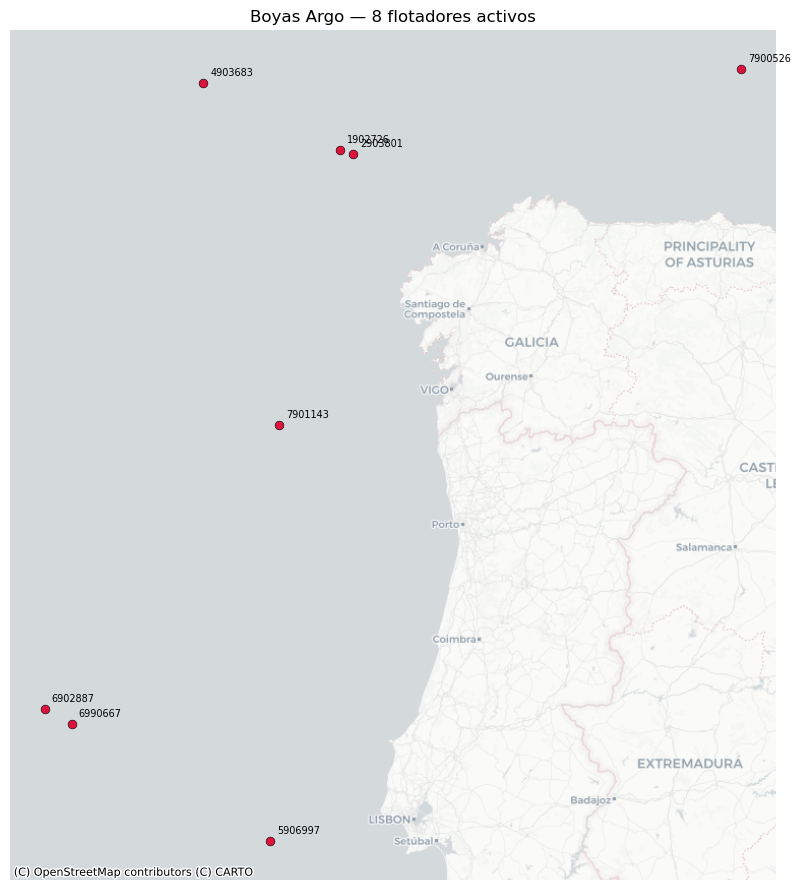

In [17]:
fig, ax = plt.subplots(figsize=(9, 9))
gdf.plot(ax=ax, color="crimson", markersize=40, edgecolor="black", linewidth=0.4, zorder=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Boyas Argo — {df_surf.PLATFORM_NUMBER.nunique()} flotadores activos")
fig.tight_layout()

for _, row in gdf.iterrows():
    ax.annotate(
        str(row["PLATFORM_NUMBER"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
        color="black",
    )

IDs y numero de ciclo de las boyas en el área (misma área que el modelo ROMS de MeteoGalicia)

In [18]:

print("Boyas y sus ciclos desde hace una semana hasta hoy")

# Obtenemos las combinaciones únicas de boya y ciclo con su fecha de registro
opciones = df[['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'TIME']].drop_duplicates(subset=['PLATFORM_NUMBER', 'CYCLE_NUMBER'])

for _, row in opciones.sort_values(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).iterrows():
    fecha_str = pd.to_datetime(row['TIME']).strftime('%Y-%m-%d %H:%M')
    print(f"ID Boya: {row['PLATFORM_NUMBER']} | Ciclo: {row['CYCLE_NUMBER']} | Fecha: {fecha_str}")

Boyas y sus ciclos desde hace una semana hasta hoy
ID Boya: 1902726 | Ciclo: 60 | Fecha: 2026-07-02 14:06
ID Boya: 2903801 | Ciclo: 27 | Fecha: 2026-07-02 05:37
ID Boya: 4903683 | Ciclo: 36 | Fecha: 2026-06-30 22:41
ID Boya: 5906997 | Ciclo: 27 | Fecha: 2026-07-02 05:48
ID Boya: 6902887 | Ciclo: 78 | Fecha: 2026-07-01 08:39
ID Boya: 6990667 | Ciclo: 71 | Fecha: 2026-07-04 20:36
ID Boya: 7900526 | Ciclo: 258 | Fecha: 2026-06-30 21:02
ID Boya: 7901143 | Ciclo: 92 | Fecha: 2026-07-02 11:40


Aquí se modifica, Elige la boya ID y su ciclo (como he puesto un máximo de boyas semanales, cada día que lo ejecutes sale distinto.)

Por otra parte, si solo quieres compararlo en un plot (es decir, en el punto exacto o casi exacto) pon N = 1.

Hablando con Dani metí el incremento de 0.25 por si la resolución del modelo no representa bien un posible eddy y tenga entonces los datos correspondientes desplazados, así se puede comprobar por una parte eso y cuando puede ser el desfase de celda de los datos (cuanto más cercano al centro mejor)

Ya por ultimo, pon una profundidad máxima. Los plots los reproduce tanto de toda la columna como con la profundidad máxima. En el caso de la profundidad máxima calcula el error cuadrático médio respecto a la boya solamente con los datos hasta esa profundidad, así que debería cambiar el valor respecto a la columna de agua hasta donde llegue la boya (osea donde hay datos)

In [19]:
MI_BOYA = 6902887
MI_CICLO = 78

# Seleccionamos el tamaño de la matriz para plotear, N x N
N = 1            # IMPORTANTE SIEMPRE IMPAR. elegir 1 solamente plotea en el punto del modelo donde ha medido la boya
paso_grados = 0.25 # incremendo en grados

PROF_MAX = 50  # Profundidad maxima para hacer los plots superficiales


Plot de los perfiles de la boya seleccionada

Cargando datos de Boya: 6902887 | Ciclo: 78
Fecha del perfil: 2026-07-01 08:39
Grafico saved en: graficos_validacion/boya_6902887/ciclo_78/perfil_boya_argo.png


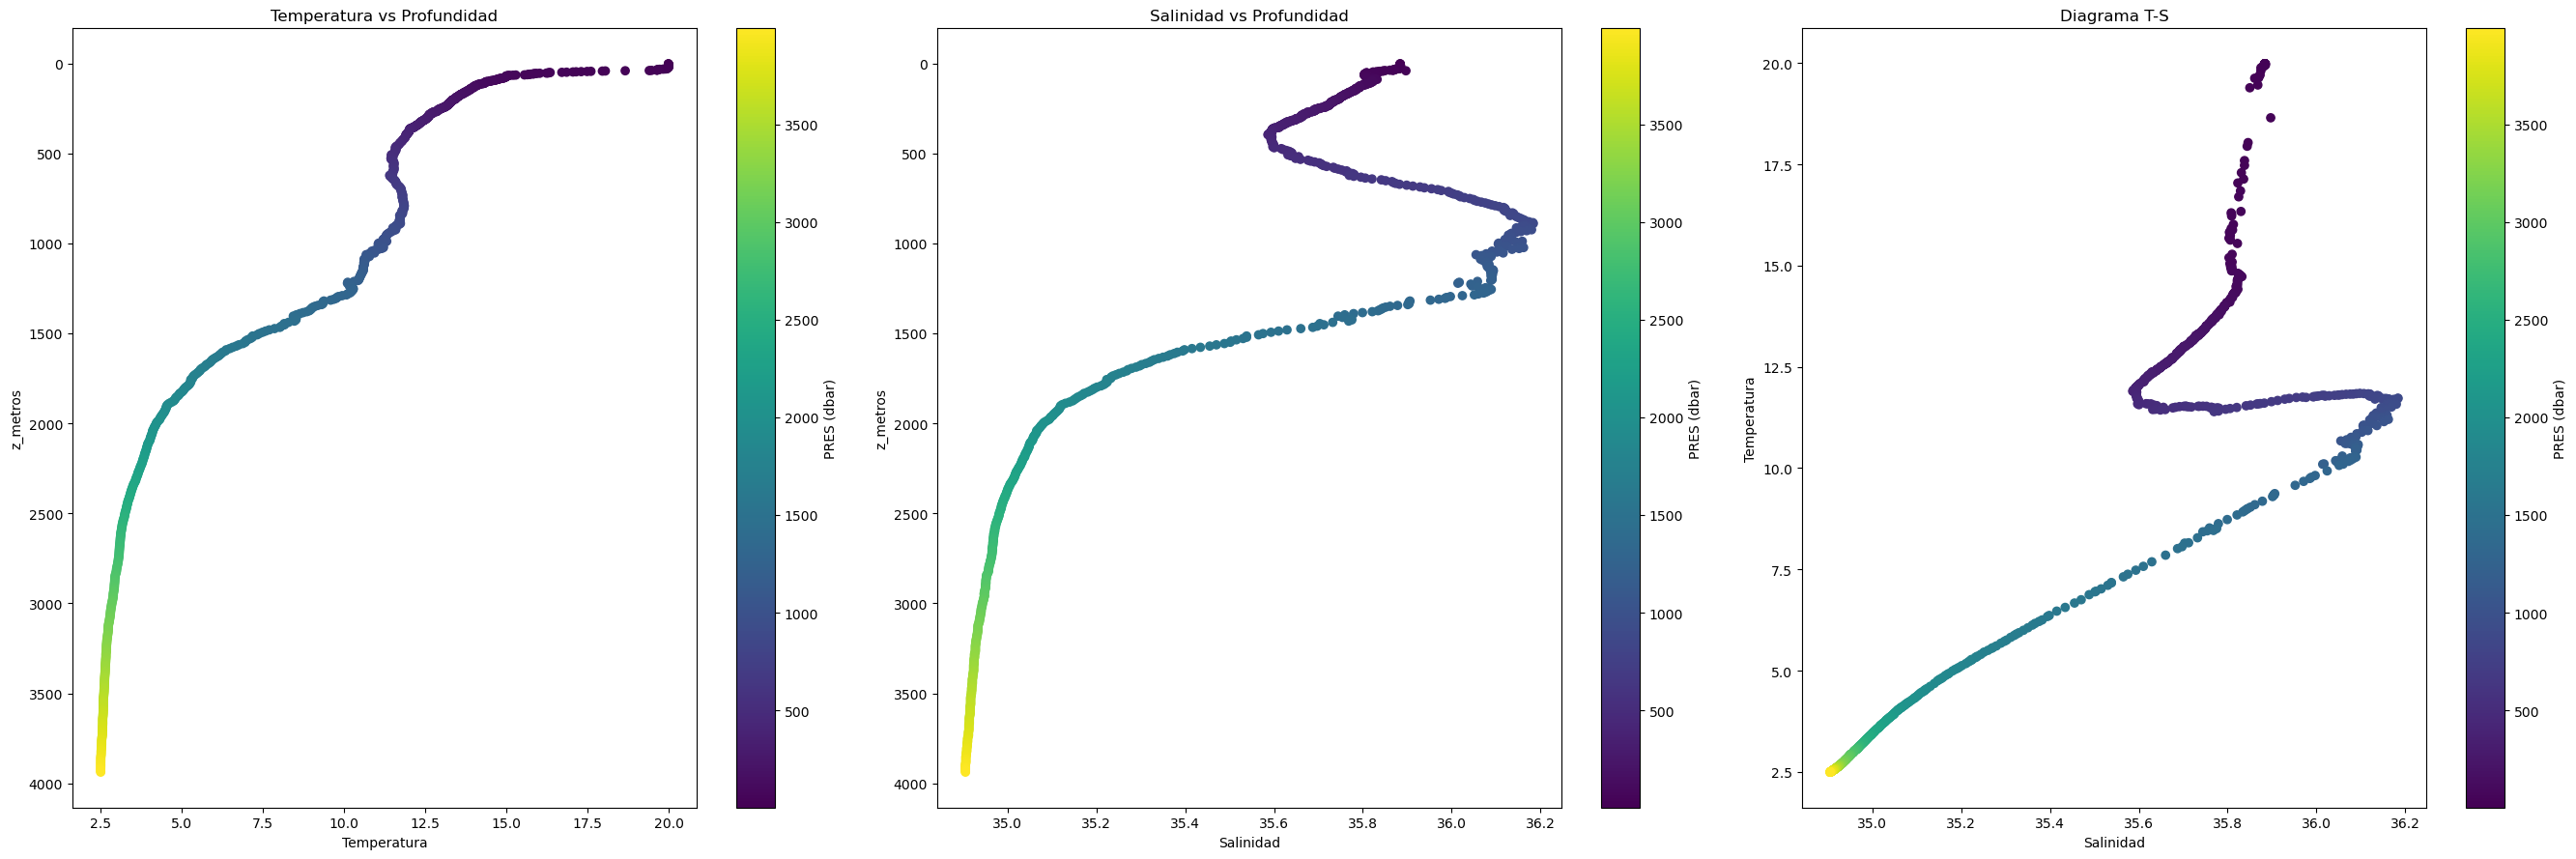

In [20]:


perfil = df[(df['PLATFORM_NUMBER'] == MI_BOYA) & (df['CYCLE_NUMBER'] == MI_CICLO)]

# Control de errores
if perfil.empty:
    print(f"No existen datos para la Boya {MI_BOYA} en el Ciclo {MI_CICLO}.")
    print("Por favor, revisa el listado de opciones e introduce una combinación válida.")
else:
    print(f"Cargando datos de Boya: {MI_BOYA} | Ciclo: {MI_CICLO}")
    print(f"Fecha del perfil: {pd.to_datetime(perfil['TIME'].iloc[0]).strftime('%Y-%m-%d %H:%M')}")

    ruta_carpeta = f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}"
    os.makedirs(ruta_carpeta, exist_ok=True)

    fig, ax = plt.subplots(1, 3, figsize=(27, 9))

    ax[0].set_title("Temperatura vs Profundidad")
    sc = ax[0].scatter(perfil['TEMP'], perfil['z_metros'], 
                       c=perfil['PRES'], cmap='viridis',
                       marker='o')
    fig.colorbar(sc, ax=ax[0], label='PRES (dbar)')
    ax[0].set_xlabel('Temperatura')
    ax[0].set_ylabel('z_metros')
    ax[0].invert_yaxis()

    ax[1].set_title("Salinidad vs Profundidad")
    sc = ax[1].scatter(perfil['PSAL'], perfil['z_metros'],
                       c=perfil['PRES'], cmap='viridis',
                       marker='o')
    fig.colorbar(sc, ax=ax[1], label='PRES (dbar)')
    ax[1].set_xlabel('Salinidad')
    ax[1].set_ylabel('z_metros')
    ax[1].invert_yaxis()  

    ax[2].set_title("Diagrama T-S")
    sc = ax[2].scatter(perfil['PSAL'], perfil['TEMP'],
                       c=perfil['PRES'], cmap='viridis',
                       marker='o')
    fig.colorbar(sc, ax=ax[2], label='PRES (dbar)')
    ax[2].set_xlabel('Salinidad')
    ax[2].set_ylabel('Temperatura')

    fig.tight_layout()
    
    ruta_guardado = f"{ruta_carpeta}/perfil_boya_argo.png"
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    print(f"Grafico saved en: {ruta_guardado}")
    
    plt.show()

Reanalisis 

In [21]:
fecha_boya = pd.to_datetime(perfil['TIME'].iloc[0])
lat_boya = perfil['LATITUDE'].iloc[0]
lon_boya = perfil['LONGITUDE'].iloc[0]

print(f"Boya seleccionada - Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")

ds_reanalisis = None 

for dias_atras in range(5):
    fecha_intento = fecha_boya - timedelta(days=dias_atras)
    fecha_inicio_str = fecha_intento.strftime("%Y%m%d")
    fecha_fin = fecha_intento + timedelta(days=1) # Ventana de 1 día
    fecha_fin_str = fecha_fin.strftime("%Y%m%d")
    
    opendap_url = (
        f"https://thredds-meteo.cesga.es/thredds/dodsC/ROMS/ROMS_RAW_output/"
        f"{fecha_inicio_str}/00/ocean_history_a{fecha_inicio_str}_{fecha_fin_str}.nc"
    )
    
    try:
        ds_intento = xr.open_dataset(opendap_url, engine='netcdf4')
        time_min = pd.to_datetime(ds_intento['ocean_time'].values.min())
        time_max = pd.to_datetime(ds_intento['ocean_time'].values.max())
        
        if time_min <= fecha_boya <= time_max:
            print(f"Reanálisis (a) cargado: {time_min.strftime('%Y-%m-%d')} a {time_max.strftime('%Y-%m-%d')}")
            ds_reanalisis = ds_intento
            break 
        else:
            ds_intento.close()
    except:
        continue

if ds_reanalisis is None:
    print("ERROR: No se encontró el Reanálisis.")
else:
    print("Variables de Reanálisis listas.")

Boya seleccionada - Fecha: 2026-07-01 08:39
Reanálisis (a) cargado: 2026-07-01 a 2026-07-02
Variables de Reanálisis listas.


Forecast

In [22]:
ds_forecast = None 

for dias_atras in range(5):
    fecha_intento = fecha_boya - timedelta(days=dias_atras)
    fecha_inicio_str = fecha_intento.strftime("%Y%m%d")
    fecha_fin = fecha_intento + timedelta(days=4) # Ventana de 4 días
    fecha_fin_str = fecha_fin.strftime("%Y%m%d")
    
    opendap_url = (
        f"https://thredds-meteo.cesga.es/thredds/dodsC/ROMS/ROMS_RAW_output/"
        f"{fecha_inicio_str}/00/ocean_history_p{fecha_inicio_str}_{fecha_fin_str}.nc"
    )
    
    try:
        ds_intento = xr.open_dataset(opendap_url, engine='netcdf4')
        time_min = pd.to_datetime(ds_intento['ocean_time'].values.min())
        time_max = pd.to_datetime(ds_intento['ocean_time'].values.max())
        
        if time_min <= fecha_boya <= time_max:
            print(f"Forecast (p) cargado: {time_min.strftime('%Y-%m-%d')} a {time_max.strftime('%Y-%m-%d')}")
            ds_forecast = ds_intento
            break 
        else:
            ds_intento.close()
    except:
        continue

if ds_forecast is None:
    print("ERROR: No se encontró el Forecast.")
else:
    print("Variables de Forecast listas.")

Forecast (p) cargado: 2026-07-01 a 2026-07-05
Variables de Forecast listas.


In [23]:
assert N % 2 != 0, "Error, N debe ser impar para garantizar un centro geométrico absoluto."
centro = N // 2
target_time = np.datetime64(fecha_boya)

# Mismo instante en ambos mdoelos
time_idx_re = np.argmin(np.abs(ds_reanalisis['ocean_time'].values - target_time))
time_idx_fc = np.argmin(np.abs(ds_forecast['ocean_time'].values - target_time))

print(f"Coincidencia temporal")
print(f"Boya: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
print(f"Reanálisis: {pd.to_datetime(ds_reanalisis['ocean_time'].values[time_idx_re]).strftime('%Y-%m-%d %H:%M')}")
print(f"Forecast:   {pd.to_datetime(ds_forecast['ocean_time'].values[time_idx_fc]).strftime('%Y-%m-%d %H:%M')}\n")
print("-" * 80)

lat_roms = ds_reanalisis['lat_rho'].values
lon_roms = ds_reanalisis['lon_rho'].values

desplazamientos_lat = [(centro - fila) * paso_grados for fila in range(N)]
desplazamientos_lon = [(columna - centro) * paso_grados for columna in range(N)]

resultados_reanalisis_matriz = {}
resultados_forecast_matriz = {}

print(f"Procesando matrices {N}x{N} de ambos modelos")

for eta_grid in range(N):
    for xi_grid in range(N):
        
        lat_objetivo = lat_boya + desplazamientos_lat[eta_grid]
        lon_objetivo = lon_boya + desplazamientos_lon[xi_grid]
        dist_matriz = (lat_roms - lat_objetivo)**2 + (lon_roms - lon_objetivo)**2
        eta_idx, xi_idx = np.unravel_index(np.argmin(dist_matriz), dist_matriz.shape)

        # Extraemos los datos con esta funcion
        def extraer_perfil(ds, t_idx, eta, xi):
            temp = ds['temp'].isel(ocean_time=t_idx, eta_rho=eta, xi_rho=xi).values
            salt = ds['salt'].isel(ocean_time=t_idx, eta_rho=eta, xi_rho=xi).values
            h = ds['h'].isel(eta_rho=eta, xi_rho=xi).values
            hc = ds['hc'].values
            Cs_r = ds['Cs_r'].values
            s_rho = ds['s_rho'].values
            Vtransform = ds['Vtransform'].values if 'Vtransform' in ds else 2
            try:
                zeta = ds['zeta'].isel(ocean_time=t_idx, eta_rho=eta, xi_rho=xi).values
            except:
                zeta = 0.0
            
            if Vtransform == 2:
                S = (hc * s_rho + h * Cs_r) / (hc + h)
                z = zeta + (zeta + h) * S
            else:
                Zo = hc * s_rho + (h - hc) * Cs_r
                z = Zo + zeta * (1 + Zo / h)
            return z, temp, salt, h

        # Reanalisis
        z_re, t_re, s_re, h_re = extraer_perfil(ds_reanalisis, time_idx_re, eta_idx, xi_idx)
        resultados_reanalisis_matriz[(eta_grid, xi_grid)] = {
            'z_roms_metros': -z_re, 'roms_temp_perfil': t_re, 'roms_salt_perfil': s_re
        }

        # Forecast
        z_fc, t_fc, s_fc, h_fc = extraer_perfil(ds_forecast, time_idx_fc, eta_idx, xi_idx)
        resultados_forecast_matriz[(eta_grid, xi_grid)] = {
            'z_roms_metros': -z_fc, 'roms_temp_perfil': t_fc, 'roms_salt_perfil': s_fc
        }

        if eta_grid == centro and xi_grid == centro:
            print(f"Nodo [{eta_grid}, {xi_grid}] -> [CENTRO/BOYA] Procesado para ambos modelos.")



Coincidencia temporal
Boya: 2026-07-01 08:39
Reanálisis: 2026-07-01 09:00
Forecast:   2026-07-01 09:00

--------------------------------------------------------------------------------
Procesando matrices 1x1 de ambos modelos
Nodo [0, 0] -> [CENTRO/BOYA] Procesado para ambos modelos.


Plot comparativo entre los perfiles de la boya y del ROMS en los puntos de las capas sigma 

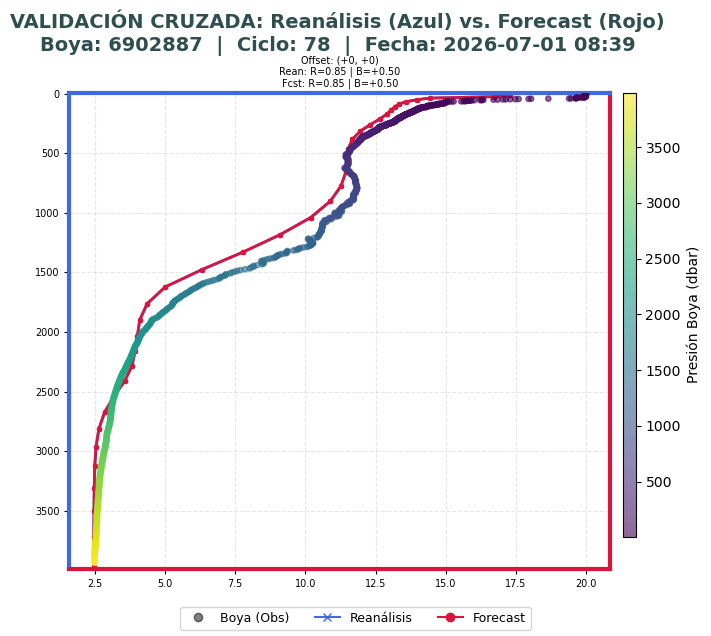

In [24]:
COLOR_REAN = 'royalblue'  # Reanálisis
COLOR_FCST = 'crimson'    # Forecast
centro = N // 2

# Datos reales de la boya
boya_temp = perfil['TEMP'].values
profundidades_boya = perfil['z_metros'].values
indices_boya_ordenados = np.argsort(profundidades_boya)
max_prof_boya = profundidades_boya.max()

# Interpolamos la boya para evaluar el RMSE
funcion_interp_boya = interp1d(
    profundidades_boya[indices_boya_ordenados], 
    boya_temp[indices_boya_ordenados], 
    kind='linear', 
    bounds_error=False, 
    fill_value=np.nan
)

z_grid_uniforme = np.linspace(0, max_prof_boya, 100)
boya_en_grid_unif = funcion_interp_boya(z_grid_uniforme)

mejor_rmse_rean = float('inf')
mejor_rmse_fcst = float('inf')
nodo_top_rean = None
nodo_top_fcst = None

for fila in range(N):
    for columna in range(N):
        # Reanálisis
        datos_rean = resultados_reanalisis_matriz.get((fila, columna), None)
        if datos_rean is not None:
            z_rean = datos_rean['z_roms_metros']
            idx_r = np.argsort(z_rean)
            z_rean_ord = z_rean[idx_r]
            temp_rean_ord = datos_rean['roms_temp_perfil'][idx_r]
            
            interp_mod_rean = interp1d(z_rean_ord, temp_rean_ord, kind='linear', bounds_error=False, fill_value=np.nan)
            rean_en_grid_unif = interp_mod_rean(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(rean_en_grid_unif)
            if np.any(mask):
                rmse_r = np.sqrt(np.mean((boya_en_grid_unif[mask] - rean_en_grid_unif[mask])**2))
                if rmse_r < mejor_rmse_rean:
                    mejor_rmse_rean = rmse_r
                    nodo_top_rean = (fila, columna)
                
        # Forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna), None)
        if datos_fcst is not None:
            z_fcst = datos_fcst['z_roms_metros']
            idx_f = np.argsort(z_fcst)
            z_fcst_ord = z_fcst[idx_f]
            temp_fcst_ord = datos_fcst['roms_temp_perfil'][idx_f]
            
            interp_mod_fcst = interp1d(z_fcst_ord, temp_fcst_ord, kind='linear', bounds_error=False, fill_value=np.nan)
            fcst_en_grid_unif = interp_mod_fcst(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(fcst_en_grid_unif)
            if np.any(mask):
                rmse_f = np.sqrt(np.mean((boya_en_grid_unif[mask] - fcst_en_grid_unif[mask])**2))
                if rmse_f < mejor_rmse_fcst:
                    mejor_rmse_fcst = rmse_f
                    nodo_top_fcst = (fila, columna)

tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)

texto_titulo = (
    f"VALIDACIÓN CRUZADA: Reanálisis (Azul) vs. Forecast (Rojo)\n"
    f"Boya: {MI_BOYA}  |  Ciclo: {MI_CICLO}  |  Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}"
)
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

sc = None

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        if resultados_reanalisis_matriz.get((fila, columna)) is None and resultados_forecast_matriz.get((fila, columna)) is None:
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue

        # Boya
        sc = ax.scatter(perfil['TEMP'], perfil['z_metros'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, zorder=3)
        
        # Reanálisis (Plot)
        datos_rean = resultados_reanalisis_matriz.get((fila, columna))
        rmse_rean, bias_rean = np.nan, np.nan
        if datos_rean is not None:
            z_rean = datos_rean['z_roms_metros']
            idx_r = np.argsort(z_rean)
            ax.plot(datos_rean['roms_temp_perfil'][idx_r], z_rean[idx_r], color=COLOR_REAN, linestyle='-', linewidth=2, marker='x', markersize=3)
            
            # Estadísticos
            interp_rean = interp1d(z_rean[idx_r], datos_rean['roms_temp_perfil'][idx_r], kind='linear', bounds_error=False, fill_value=np.nan)
            r_unif = interp_rean(z_grid_uniforme)
            m_r = ~np.isnan(boya_en_grid_unif) & ~np.isnan(r_unif)
            if np.any(m_r):
                rmse_rean = np.sqrt(np.mean((boya_en_grid_unif[m_r] - r_unif[m_r])**2))
                bias_rean = np.mean(boya_en_grid_unif[m_r] - r_unif[m_r])

        # Forecast (Plot)
        datos_fcst = resultados_forecast_matriz.get((fila, columna))
        rmse_fcst, bias_fcst = np.nan, np.nan
        if datos_fcst is not None:
            z_fcst = datos_fcst['z_roms_metros']
            idx_f = np.argsort(z_fcst)
            ax.plot(datos_fcst['roms_temp_perfil'][idx_f], z_fcst[idx_f], color=COLOR_FCST, linestyle='-', linewidth=2, marker='o', markersize=3)
            
            interp_fcst = interp1d(z_fcst[idx_f], datos_fcst['roms_temp_perfil'][idx_f], kind='linear', bounds_error=False, fill_value=np.nan)
            f_unif = interp_fcst(z_grid_uniforme)
            m_f = ~np.isnan(boya_en_grid_unif) & ~np.isnan(f_unif)
            if np.any(m_f):
                rmse_fcst = np.sqrt(np.mean((boya_en_grid_unif[m_f] - f_unif[m_f])**2))
                bias_fcst = np.mean(boya_en_grid_unif[m_f] - f_unif[m_f])

        txt_stats = (f"Offset: ({centro - fila:+,}, {columna - centro:+,})\n"
                     f"Rean: R={rmse_rean:.2f} | B={bias_rean:+.2f}\n"
                     f"Fcst: R={rmse_fcst:.2f} | B={bias_fcst:+.2f}")
        ax.set_title(txt_stats, fontsize=7, pad=4)
        
        es_top_rean = ((fila, columna) == nodo_top_rean)
        es_top_fcst = ((fila, columna) == nodo_top_fcst)
        
        if es_top_rean or es_top_fcst:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            if es_top_rean and es_top_fcst:
                ax.spines['top'].set_color(COLOR_REAN); ax.spines['left'].set_color(COLOR_REAN)
                ax.spines['bottom'].set_color(COLOR_FCST); ax.spines['right'].set_color(COLOR_FCST)
            elif es_top_rean:
                for spine in ax.spines.values(): spine.set_color(COLOR_REAN)
            elif es_top_fcst:
                for spine in ax.spines.values(): spine.set_color(COLOR_FCST)

        ax.invert_yaxis()
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)

for ax in axes.flat: ax.set_ylim(max_prof_boya + 50, -10)
plt.tight_layout()
fig.subplots_adjust(top=0.85, bottom=0.1, right=0.93)

leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label="Boya (Obs)"),
    plt.Line2D([0], [0], color=COLOR_REAN, marker='x', label="Reanálisis"),
    plt.Line2D([0], [0], color=COLOR_FCST, marker='o', label="Forecast")
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')

plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/comparativa_temperatura_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

Temperatura para la superficie

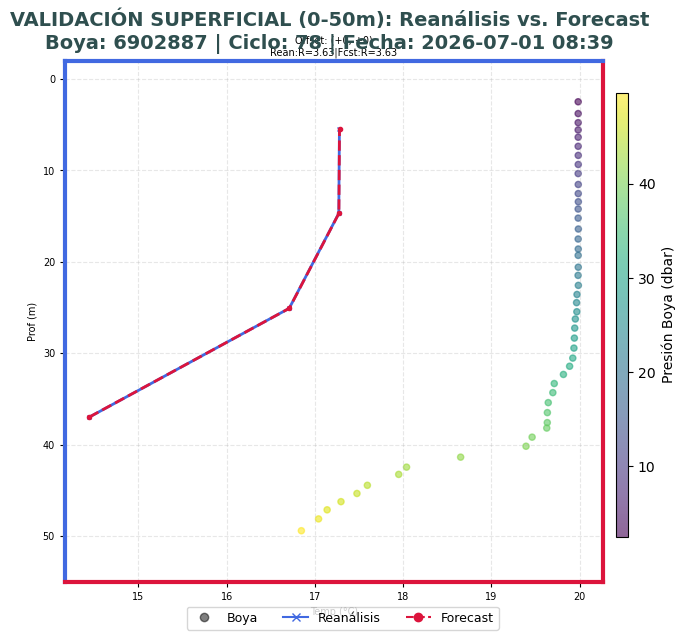

In [25]:
#PROF_MAX = 50
COLOR_REAN = 'royalblue'
COLOR_FCST = 'crimson'
centro = N // 2

# Interpolador de la boya
indices_boya_ordenados = np.argsort(perfil['z_metros'].values)
funcion_interp_boya = interp1d(
    perfil['z_metros'].values[indices_boya_ordenados], 
    perfil['TEMP'].values[indices_boya_ordenados], 
    kind='linear', bounds_error=False, fill_value=np.nan
)

z_grid_uniforme = np.linspace(0, PROF_MAX, 100)
boya_en_grid_unif = funcion_interp_boya(z_grid_uniforme)

mejor_rmse_rean = float('inf')
mejor_rmse_fcst = float('inf')
nodo_top_rean = None
nodo_top_fcst = None

for fila in range(N):
    for columna in range(N):
        # Reanalisis
        datos_rean = resultados_reanalisis_matriz.get((fila, columna))
        if datos_rean is not None:
            z_rean = datos_rean['z_roms_metros']
            idx_r = np.argsort(z_rean)
            interp_mod_rean = interp1d(z_rean[idx_r], datos_rean['roms_temp_perfil'][idx_r], kind='linear', bounds_error=False, fill_value=np.nan)
            rean_unif = interp_mod_rean(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(rean_unif)
            if np.any(mask):
                rmse_r = np.sqrt(np.mean((boya_en_grid_unif[mask] - rean_unif[mask])**2))
                if rmse_r < mejor_rmse_rean:
                    mejor_rmse_rean, nodo_top_rean = rmse_r, (fila, columna)
        
        # Forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna))
        if datos_fcst is not None:
            z_fcst = datos_fcst['z_roms_metros']
            idx_f = np.argsort(z_fcst)
            interp_mod_fcst = interp1d(z_fcst[idx_f], datos_fcst['roms_temp_perfil'][idx_f], kind='linear', bounds_error=False, fill_value=np.nan)
            fcst_unif = interp_mod_fcst(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(fcst_unif)
            if np.any(mask):
                rmse_f = np.sqrt(np.mean((boya_en_grid_unif[mask] - fcst_unif[mask])**2))
                if rmse_f < mejor_rmse_fcst:
                    mejor_rmse_fcst, nodo_top_fcst = rmse_f, (fila, columna)


tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), squeeze=False)

texto_titulo = (f"VALIDACIÓN SUPERFICIAL (0-{PROF_MAX}m): Reanálisis vs. Forecast\n"
                f"Boya: {MI_BOYA} | Ciclo: {MI_CICLO} | Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

mask_boya = (perfil['z_metros'] <= PROF_MAX)
sc = None

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        # Boya
        sc = ax.scatter(perfil['TEMP'][mask_boya], perfil['z_metros'][mask_boya], 
                        c=perfil['PRES'][mask_boya], cmap='viridis', alpha=0.6, s=20, label="Boya (Obs)")
        
        # Reanálisis
        datos_rean = resultados_reanalisis_matriz.get((fila, columna))
        rmse_rean, bias_rean = np.nan, np.nan
        if datos_rean is not None:
            z_r, t_r = datos_rean['z_roms_metros'], datos_rean['roms_temp_perfil']
            mask_r = (z_r <= PROF_MAX)
            if np.any(mask_r):
                ax.plot(t_r[mask_r], z_r[mask_r], color=COLOR_REAN, linewidth=2, marker='x', markersize=3)
                rean_unif = interp1d(z_r, t_r, kind='linear', bounds_error=False, fill_value=np.nan)(z_grid_uniforme)
                m = ~np.isnan(boya_en_grid_unif) & ~np.isnan(rean_unif)
                if np.any(m):
                    rmse_rean = np.sqrt(np.mean((boya_en_grid_unif[m] - rean_unif[m])**2))
                    bias_rean = np.mean(boya_en_grid_unif[m] - rean_unif[m])

        # Forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna))
        rmse_fcst, bias_fcst = np.nan, np.nan
        if datos_fcst is not None:
            z_f, t_f = datos_fcst['z_roms_metros'], datos_fcst['roms_temp_perfil']
            mask_f = (z_f <= PROF_MAX)
            if np.any(mask_f):
                ax.plot(t_f[mask_f], z_f[mask_f], color=COLOR_FCST, linestyle='--', linewidth=2, marker='o', markersize=3)
                fcst_unif = interp1d(z_f, t_f, kind='linear', bounds_error=False, fill_value=np.nan)(z_grid_uniforme)
                m = ~np.isnan(boya_en_grid_unif) & ~np.isnan(fcst_unif)
                if np.any(m):
                    rmse_fcst = np.sqrt(np.mean((boya_en_grid_unif[m] - fcst_unif[m])**2))
                    bias_fcst = np.mean(boya_en_grid_unif[m] - fcst_unif[m])

        ax.set_title(f"Offset: ({centro-fila:+,}, {columna-centro:+})\nRean:R={rmse_rean:.2f}|Fcst:R={rmse_fcst:.2f}", fontsize=7, pad=4)

        # Lógica de resaltado corregida
        es_top_rean = ((fila, columna) == nodo_top_rean)
        es_top_fcst = ((fila, columna) == nodo_top_fcst)

        if es_top_rean or es_top_fcst:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            
            if es_top_rean and es_top_fcst:
                ax.spines['top'].set_color(COLOR_REAN); ax.spines['left'].set_color(COLOR_REAN)
                ax.spines['bottom'].set_color(COLOR_FCST); ax.spines['right'].set_color(COLOR_FCST)
            elif es_top_rean:
                for spine in ax.spines.values(): spine.set_color(COLOR_REAN)
            elif es_top_fcst:
                for spine in ax.spines.values(): spine.set_color(COLOR_FCST)

        ax.invert_yaxis()
        ax.set_ylim(PROF_MAX + 5, -2)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        ax.set_xlabel('Temp (°C)', fontsize=7)
        ax.set_ylabel('Prof (m)', fontsize=7)
        ax.tick_params(labelbottom=True, labelleft=True, labelsize=7)

plt.tight_layout()
fig.subplots_adjust(top=0.90, right=0.93)
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')

handles = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label="Boya"),
    plt.Line2D([0], [0], color=COLOR_REAN, marker='x', label="Reanálisis"),
    plt.Line2D([0], [0], color=COLOR_FCST, marker='o', linestyle='--', label="Forecast")
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9)
plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/comparativa_temperatura_superficial_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

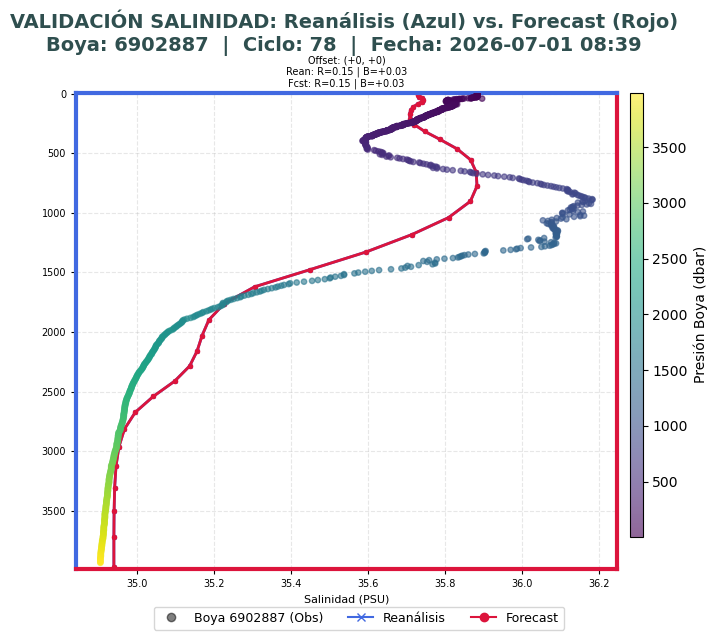

In [32]:
COLOR_REAN = 'royalblue'  # Reanálisis
COLOR_FCST = 'crimson'    # Forecast
centro = N // 2

boya_salt = perfil['PSAL'].values
profundidades_boya = perfil['z_metros'].values
indices_boya_ordenados = np.argsort(profundidades_boya)
max_prof_boya = profundidades_boya.max()

funcion_interp_boya = interp1d(
    profundidades_boya[indices_boya_ordenados], 
    boya_salt[indices_boya_ordenados], 
    kind='linear', 
    bounds_error=False, 
    fill_value=np.nan
)

z_grid_uniforme = np.linspace(0, max_prof_boya, 100)
boya_en_grid_unif = funcion_interp_boya(z_grid_uniforme)

mejor_rmse_rean = float('inf')
mejor_rmse_fcst = float('inf')
nodo_top_rean = None
nodo_top_fcst = None

# Calculo del RMSE
for fila in range(N):
    for columna in range(N):
        # Reanalisis
        datos_rean = resultados_reanalisis_matriz.get((fila, columna), None)
        if datos_rean is not None:
            z_rean = datos_rean['z_roms_metros']
            idx_r = np.argsort(z_rean)
            z_rean_ord = z_rean[idx_r]
            salt_rean_ord = datos_rean['roms_salt_perfil'][idx_r]
            
            interp_mod_rean = interp1d(z_rean_ord, salt_rean_ord, kind='linear', bounds_error=False, fill_value=np.nan)
            rean_en_grid_unif = interp_mod_rean(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(rean_en_grid_unif)
            if np.any(mask):
                rmse_r = np.sqrt(np.mean((boya_en_grid_unif[mask] - rean_en_grid_unif[mask])**2))
                if rmse_r < mejor_rmse_rean:
                    mejor_rmse_rean = rmse_r
                    nodo_top_rean = (fila, columna)
                
        # Forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna), None)
        if datos_fcst is not None:
            z_fcst = datos_fcst['z_roms_metros']
            idx_f = np.argsort(z_fcst)
            z_fcst_ord = z_fcst[idx_f]
            salt_fcst_ord = datos_fcst['roms_salt_perfil'][idx_f]
            
            interp_mod_fcst = interp1d(z_fcst_ord, salt_fcst_ord, kind='linear', bounds_error=False, fill_value=np.nan)
            fcst_en_grid_unif = interp_mod_fcst(z_grid_uniforme)
            
            mask = ~np.isnan(boya_en_grid_unif) & ~np.isnan(fcst_en_grid_unif)
            if np.any(mask):
                rmse_f = np.sqrt(np.mean((boya_en_grid_unif[mask] - fcst_en_grid_unif[mask])**2))
                if rmse_f < mejor_rmse_fcst:
                    mejor_rmse_fcst = rmse_f
                    nodo_top_fcst = (fila, columna)

tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), sharex=True, sharey=True, squeeze=False)

texto_titulo = (
    f"VALIDACIÓN SALINIDAD: Reanálisis (Azul) vs. Forecast (Rojo)\n"
    f"Boya: {MI_BOYA}  |  Ciclo: {MI_CICLO}  |  Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}"
)
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

sc = None

for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        if resultados_reanalisis_matriz.get((fila, columna)) is None and resultados_forecast_matriz.get((fila, columna)) is None:
            ax.text(0.5, 0.5, "Sin Datos", ha='center', va='center', color='gray')
            ax.grid(True, linestyle='--', alpha=0.3)
            continue

        # Boya
        sc = ax.scatter(perfil['PSAL'], perfil['z_metros'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, zorder=3)
        
        # Plot reanalsisi
        datos_rean = resultados_reanalisis_matriz.get((fila, columna))
        rmse_rean, bias_rean = np.nan, np.nan
        if datos_rean is not None:
            z_rean = datos_rean['z_roms_metros']
            idx_r = np.argsort(z_rean)
            ax.plot(datos_rean['roms_salt_perfil'][idx_r], z_rean[idx_r], color=COLOR_REAN, linestyle='-', linewidth=2, marker='x', markersize=3)
            
            interp_rean = interp1d(z_rean[idx_r], datos_rean['roms_salt_perfil'][idx_r], kind='linear', bounds_error=False, fill_value=np.nan)
            r_unif = interp_rean(z_grid_uniforme)
            m_r = ~np.isnan(boya_en_grid_unif) & ~np.isnan(r_unif)
            if np.any(m_r):
                rmse_rean = np.sqrt(np.mean((boya_en_grid_unif[m_r] - r_unif[m_r])**2))
                bias_rean = np.mean(boya_en_grid_unif[m_r] - r_unif[m_r])

        # Plot forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna))
        rmse_fcst, bias_fcst = np.nan, np.nan
        if datos_fcst is not None:
            z_fcst = datos_fcst['z_roms_metros']
            idx_f = np.argsort(z_fcst)
            ax.plot(datos_fcst['roms_salt_perfil'][idx_f], z_fcst[idx_f], color=COLOR_FCST, linestyle='-', linewidth=2, marker='o', markersize=3)
            
            interp_fcst = interp1d(z_fcst[idx_f], datos_fcst['roms_salt_perfil'][idx_f], kind='linear', bounds_error=False, fill_value=np.nan)
            f_unif = interp_fcst(z_grid_uniforme)
            m_f = ~np.isnan(boya_en_grid_unif) & ~np.isnan(f_unif)
            if np.any(m_f):
                rmse_fcst = np.sqrt(np.mean((boya_en_grid_unif[m_f] - f_unif[m_f])**2))
                bias_fcst = np.mean(boya_en_grid_unif[m_f] - f_unif[m_f])

        txt_stats = (f"Offset: ({centro - fila:+,}, {columna - centro:+,})\n"
                     f"Rean: R={rmse_rean:.2f} | B={bias_rean:+.2f}\n"
                     f"Fcst: R={rmse_fcst:.2f} | B={bias_fcst:+.2f}")
        ax.set_title(txt_stats, fontsize=7, pad=4)
        
        es_top_rean = ((fila, columna) == nodo_top_rean)
        es_top_fcst = ((fila, columna) == nodo_top_fcst)
        
        if es_top_rean or es_top_fcst:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            if es_top_rean and es_top_fcst:
                ax.spines['top'].set_color(COLOR_REAN); ax.spines['left'].set_color(COLOR_REAN)
                ax.spines['bottom'].set_color(COLOR_FCST); ax.spines['right'].set_color(COLOR_FCST)
            elif es_top_rean:
                for spine in ax.spines.values(): spine.set_color(COLOR_REAN)
            elif es_top_fcst:
                for spine in ax.spines.values(): spine.set_color(COLOR_FCST)

        ax.invert_yaxis()
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.set_xlabel('Salinidad (PSU)', fontsize=8)

for ax in axes.flat: ax.set_ylim(max_prof_boya + 50, -10)
plt.tight_layout()
fig.subplots_adjust(top=0.85, bottom=0.1, right=0.93)

leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label=f"Boya {MI_BOYA} (Obs)"),
    plt.Line2D([0], [0], color=COLOR_REAN, marker='x', label="Reanálisis"),
    plt.Line2D([0], [0], color=COLOR_FCST, marker='o', label="Forecast")
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')

plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/comparativa_salinidad_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

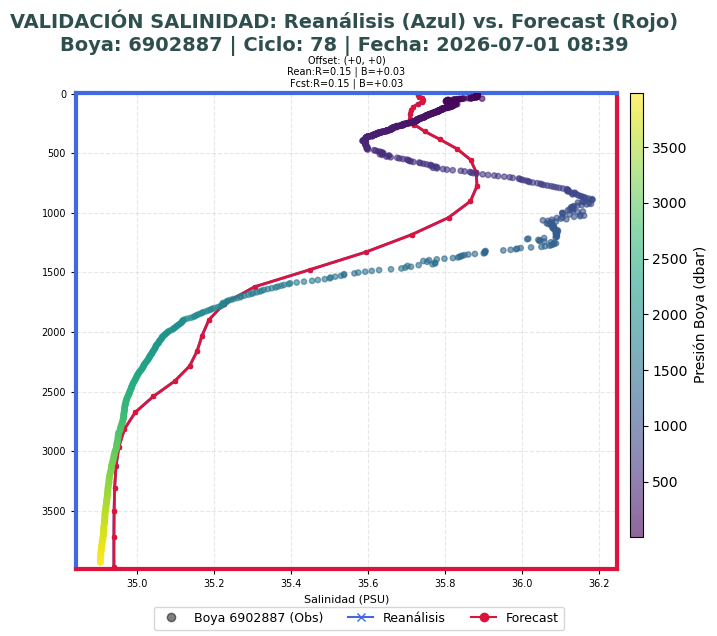

In [ ]:
tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), squeeze=False)

texto_titulo = (f"VALIDACIÓN SALINIDAD: Reanálisis (Azul) vs. Forecast (Rojo)\n"
                f"Boya: {MI_BOYA} | Ciclo: {MI_CICLO} | Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

sc = None
for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        # Boya
        sc = ax.scatter(perfil['PSAL'], perfil['z_metros'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, zorder=3)
        
        # Reanálisis
        datos_rean = resultados_reanalisis_matriz.get((fila, columna))
        rmse_rean, bias_rean = np.nan, np.nan
        if datos_rean is not None:
            z_rean = datos_rean['z_roms_metros']
            idx_r = np.argsort(z_rean)
            ax.plot(datos_rean['roms_salt_perfil'][idx_r], z_rean[idx_r], color=COLOR_REAN, linestyle='-', linewidth=2, marker='x', markersize=3)
            
            interp_rean = interp1d(z_rean[idx_r], datos_rean['roms_salt_perfil'][idx_r], kind='linear', bounds_error=False, fill_value=np.nan)
            r_unif = interp_rean(z_grid_uniforme)
            m_r = ~np.isnan(boya_en_grid_unif) & ~np.isnan(r_unif)
            if np.any(m_r):
                rmse_rean = np.sqrt(np.mean((boya_en_grid_unif[m_r] - r_unif[m_r])**2))
                bias_rean = np.mean(boya_en_grid_unif[m_r] - r_unif[m_r])

        # Forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna))
        rmse_fcst, bias_fcst = np.nan, np.nan
        if datos_fcst is not None:
            z_fcst = datos_fcst['z_roms_metros']
            idx_f = np.argsort(z_fcst)
            ax.plot(datos_fcst['roms_salt_perfil'][idx_f], z_fcst[idx_f], color=COLOR_FCST, linestyle='-', linewidth=2, marker='o', markersize=3)
            
            interp_fcst = interp1d(z_fcst[idx_f], datos_fcst['roms_salt_perfil'][idx_f], kind='linear', bounds_error=False, fill_value=np.nan)
            f_unif = interp_fcst(z_grid_uniforme)
            m_f = ~np.isnan(boya_en_grid_unif) & ~np.isnan(f_unif)
            if np.any(m_f):
                rmse_fcst = np.sqrt(np.mean((boya_en_grid_unif[m_f] - f_unif[m_f])**2))
                bias_fcst = np.mean(boya_en_grid_unif[m_f] - f_unif[m_f])

        ax.set_title(f"Offset: ({centro - fila:+,}, {columna - centro:+})\nRean:R={rmse_rean:.2f} | B={bias_rean:+.2f}\nFcst:R={rmse_fcst:.2f} | B={bias_fcst:+.2f}", fontsize=7, pad=4)
        
        # Bordes
        es_top_rean = ((fila, columna) == nodo_top_rean)
        es_top_fcst = ((fila, columna) == nodo_top_fcst)
        
        if es_top_rean or es_top_fcst:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            if es_top_rean and es_top_fcst:
                ax.spines['top'].set_color(COLOR_REAN); ax.spines['left'].set_color(COLOR_REAN)
                ax.spines['bottom'].set_color(COLOR_FCST); ax.spines['right'].set_color(COLOR_FCST)
            elif es_top_rean:
                for spine in ax.spines.values(): spine.set_color(COLOR_REAN)
            elif es_top_fcst:
                for spine in ax.spines.values(): spine.set_color(COLOR_FCST)

        ax.invert_yaxis()
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.set_xlabel('Salinidad (PSU)', fontsize=8)

for ax in axes.flat: ax.set_ylim(max_prof_boya + 50, -10)
plt.tight_layout(rect=[0, 0.05, 1, 0.95], h_pad=2.5)
fig.subplots_adjust(top=0.85, bottom=0.1, right=0.93)

leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label=f"Boya {MI_BOYA} (Obs)"),
    plt.Line2D([0], [0], color=COLOR_REAN, marker='x', label="Reanálisis"),
    plt.Line2D([0], [0], color=COLOR_FCST, marker='o', label="Forecast")
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')

plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/comparativa_salinidad_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()

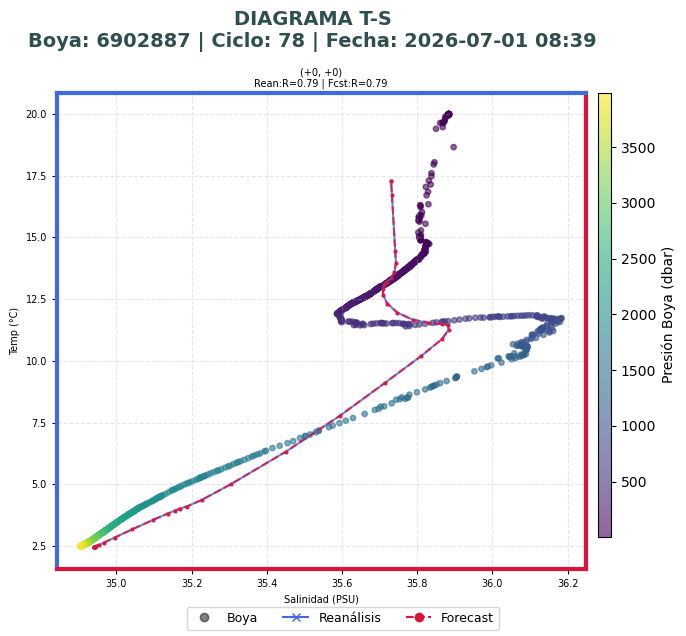

In [ ]:
tamano_celda = 6.5 - (N * 0.15)
fig, axes = plt.subplots(N, N, figsize=(N * tamano_celda, N * tamano_celda), squeeze=False)

texto_titulo = (f"DIAGRAMA T-S\n"
                f"Boya: {MI_BOYA} | Ciclo: {MI_CICLO} | Fecha: {fecha_boya.strftime('%Y-%m-%d %H:%M')}")
fig.suptitle(texto_titulo, fontsize=14, fontweight='bold', color='darkslategray', y=0.98)

sc = None
for fila in range(N):
    for columna in range(N):
        ax = axes[fila, columna]
        
        # Boya
        sc = ax.scatter(perfil['PSAL'], perfil['TEMP'], 
                        c=perfil['PRES'], cmap='viridis', alpha=0.6, s=15, label="Boya")
        
        # Reanálisis
        datos_rean = resultados_reanalisis_matriz.get((fila, columna))
        rmse_rean_plot = np.nan
        if datos_rean is not None:
            ax.plot(datos_rean['roms_salt_perfil'], datos_rean['roms_temp_perfil'], 
                    color=COLOR_REAN, linewidth=1.5, alpha=0.8, marker='x', markersize=2)
            r_temp = interp1d(datos_rean['z_roms_metros'], datos_rean['roms_temp_perfil'], kind='linear', bounds_error=False)(z_grid)
            r_psal = interp1d(datos_rean['z_roms_metros'], datos_rean['roms_salt_perfil'], kind='linear', bounds_error=False)(z_grid)
            mask = ~np.isnan(temp_boya_unif) & ~np.isnan(r_temp)
            if np.any(mask): rmse_rean_plot = np.sqrt(np.mean((temp_boya_unif[mask] - r_temp[mask])**2 + (psal_boya_unif[mask] - r_psal[mask])**2))

        # Forecast
        datos_fcst = resultados_forecast_matriz.get((fila, columna))
        rmse_fcst_plot = np.nan
        if datos_fcst is not None:
            ax.plot(datos_fcst['roms_salt_perfil'], datos_fcst['roms_temp_perfil'], 
                    color=COLOR_FCST, linewidth=1.5, alpha=0.8, linestyle='--', marker='o', markersize=2)
            f_temp = interp1d(datos_fcst['z_roms_metros'], datos_fcst['roms_temp_perfil'], kind='linear', bounds_error=False)(z_grid)
            f_psal = interp1d(datos_fcst['z_roms_metros'], datos_fcst['roms_salt_perfil'], kind='linear', bounds_error=False)(z_grid)
            mask = ~np.isnan(temp_boya_unif) & ~np.isnan(f_temp)
            if np.any(mask): rmse_fcst_plot = np.sqrt(np.mean((temp_boya_unif[mask] - f_temp[mask])**2 + (psal_boya_unif[mask] - f_psal[mask])**2))

        ax.set_title(f"({centro-fila:+,}, {columna-centro:+})\nRean:R={rmse_rean_plot:.2f} | Fcst:R={rmse_fcst_plot:.2f}", fontsize=7, pad=4)

        # Bordes
        es_top_rean = ((fila, columna) == nodo_top_rean)
        es_top_fcst = ((fila, columna) == nodo_top_fcst)
        if es_top_rean or es_top_fcst:
            for spine in ax.spines.values(): spine.set_linewidth(3.0)
            if es_top_rean and es_top_fcst:
                ax.spines['top'].set_color(COLOR_REAN); ax.spines['left'].set_color(COLOR_REAN)
                ax.spines['bottom'].set_color(COLOR_FCST); ax.spines['right'].set_color(COLOR_FCST)
            elif es_top_rean:
                for spine in ax.spines.values(): spine.set_color(COLOR_REAN)
            elif es_top_fcst:
                for spine in ax.spines.values(): spine.set_color(COLOR_FCST)

        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_xlabel('Salinidad (PSU)', fontsize=7)
        ax.set_ylabel('Temp (°C)', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout(rect=[0, 0.05, 1, 0.95], h_pad=2.5)
fig.subplots_adjust(top=0.85, bottom=0.1, right=0.93)

leyenda = [
    plt.Line2D([0], [0], color='black', marker='o', linestyle='', alpha=0.5, label="Boya"),
    plt.Line2D([0], [0], color=COLOR_REAN, marker='x', label="Reanálisis"),
    plt.Line2D([0], [0], color=COLOR_FCST, marker='o', linestyle='--', label="Forecast")
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9)

cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Presión Boya (dbar)')

plt.savefig(f"graficos_validacion/boya_{MI_BOYA}/ciclo_{MI_CICLO}/diagrama_ts_{N}x{N}.png", dpi=300, bbox_inches='tight')
plt.show()